# 06 - Trajectory Prediction

## Imports

In [1]:
import warnings
# A known benign quirk on some numpy 2.x + Apple Accelerate BLAS setups: certain matmul
# shapes emit spurious floating-point RuntimeWarnings with no actual NaN/Inf in the
# result (confirmed below) - not something wrong with the math in this notebook.
warnings.filterwarnings('ignore', category=RuntimeWarning)

import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## Beyond Constant Velocity

`perception_primer/05-objects-in-motion.ipynb` built a Kalman filter that predicts an object's next position assuming constant velocity, and flagged its own limit directly: *"there are many scenarios where an object in motion does not maintain constant velocity or acceleration - a ball could get knocked off course by another ball or a robot, for instance... we turn to more advanced ML techniques... to make predictions based on variable velocity and/or acceleration."* This notebook is that: forecasting an opponent robot's future path from a history of observed positions, without assuming it's moving in a straight line at a fixed speed.

This is worth being clear about up front: it's necessarily a *vision* problem, not an odometry one. `back_end_resources/systems_primer/04b_motion_control_and_trajectories` covers odometry - but that's built from *our own* wheel encoders and gyro, sensors we have no access to on an opponent's robot. Everything we can ever know about an opponent's motion has to come from tracking it through our own camera - the detection, Kalman filter, and Hungarian Algorithm pipeline (SORT) `perception_primer/05` already built.

## From One Step to a Window

The Kalman filter's constant-velocity model effectively looks at only the two most recent positions to estimate a single velocity vector, then extrapolates that velocity forever. This notebook instead gives a model a **History Window** of the last $K$ observed positions as input, and asks it to predict a **Prediction Horizon** of the next $M$ positions - enough history that a model can pick up on **curvature** (a path that's already turning) instead of only ever seeing where the object was one instant ago.

## Building a Synthetic "Juking Opponent" Dataset

We'll generate synthetic trajectories along circular arcs - random radius, direction, and speed - which turn smoothly and consistently, the way a robot driving a curve actually would. The kinematics are exactly the same integration `back_end_resources/systems_primer/04b_motion_control_and_trajectories`'s `OdometryDemo.java` used to track a robot's *own* position (`heading += angular velocity * dt`, then step forward along that heading) - here we're using it to *generate* an opponent's ground-truth motion instead of estimating our own.

In [2]:
DT = 0.1          # seconds per tick (arbitrary units - the shape of the curve is what matters)
K = 5             # history window: how many past positions the model sees
M = 5             # prediction horizon: how many future positions to predict
NOISE_STD = 0.02  # small sensor noise on every observed position, like the Kalman filter demo

def generate_trajectory(rng):
    radius_magnitude = rng.uniform(1.5, 6.0)
    radius = radius_magnitude * rng.choice([-1, 1])   # sign picks turn direction
    speed = rng.uniform(0.5, 1.5)
    angular_velocity = speed / radius

    heading, x, y = 0.0, 0.0, 0.0
    positions = []
    for _ in range(K + M):
        positions.append((x + rng.normal(0, NOISE_STD), y + rng.normal(0, NOISE_STD)))
        heading += angular_velocity * DT
        x += speed * DT * np.cos(heading)
        y += speed * DT * np.sin(heading)
    return np.array(positions)   # shape (K + M, 2)

def make_dataset(n, rng):
    """Each example: K past positions (relative to the most recent one) as input,
    M future positions (relative to that same point) as the target."""
    xs, ys = [], []
    for _ in range(n):
        trajectory = generate_trajectory(rng)
        history, future = trajectory[:K], trajectory[K:K + M]
        anchor = history[-1]   # the most recent observed position
        xs.append((history - anchor).flatten())
        ys.append((future - anchor).flatten())
    return np.array(xs).T, np.array(ys).T   # shape (2*K or 2*M, n)

rng = np.random.default_rng(1515)
X_train, Y_train = make_dataset(2000, rng)
X_test, Y_test = make_dataset(200, rng)
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}, X_test: {X_test.shape}")

X_train: (10, 2000), Y_train: (10, 2000), X_test: (10, 200)


Both input and target are expressed *relative to the most recent observed position*, not raw field coordinates - the shape of a curve looks the same regardless of where on the field it happens, and a model shouldn't have to relearn the same curvature pattern separately for every possible starting point.

## Baseline: Constant-Velocity Extrapolation

Before building a learned model, we need something to beat. This baseline is exactly the Kalman filter's own assumption, without the filtering: estimate velocity from the last two observed positions, then extrapolate that fixed velocity forward for the entire prediction horizon.

In [3]:
def constant_velocity_baseline(X):
    n = X.shape[1]
    predictions = np.zeros((2 * M, n))
    for i in range(n):
        history = X[:, i].reshape(K, 2)
        velocity = (history[-1] - history[-2]) / DT
        for step in range(M):
            predictions[2 * step:2 * step + 2, i] = velocity * DT * (step + 1)
    return predictions

def per_step_rmse(predictions, targets):
    errors = []
    for step in range(M):
        diff = predictions[2 * step:2 * step + 2] - targets[2 * step:2 * step + 2]
        errors.append(np.sqrt(np.mean(np.sum(diff ** 2, axis=0))))
    return errors

baseline_predictions = constant_velocity_baseline(X_test)
baseline_errors = per_step_rmse(baseline_predictions, Y_test)
for step, err in enumerate(baseline_errors, start=1):
    print(f"  step {step}: baseline RMSE = {err:.4f}")

  step 1: baseline RMSE = 0.0675
  step 2: baseline RMSE = 0.1025
  step 3: baseline RMSE = 0.1398
  step 4: baseline RMSE = 0.1796
  step 5: baseline RMSE = 0.2221


Error should grow with each step further into the horizon - a straight-line extrapolation drifts further from a curving true path the longer it's allowed to run.

## A Learned Model: Using the Whole Window

Recall `deep_learning_primer/01-backpropagation-and-function-approximation.ipynb`'s hand-built network. The shape here is identical - a Regression Head, trained with the same backpropagation - just with a wider input (all $K$ past positions, not one number) and a wider output (all $M$ future positions, not one). Nothing about the network itself is new; only what it's mapping is.

In [4]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def forward(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    a1 = relu(z1)
    y = W2 @ a1 + b2
    return z1, a1, y

in_dim, hidden_dim, out_dim = 2 * K, 16, 2 * M
W1 = np.random.randn(hidden_dim, in_dim) * (1 / np.sqrt(in_dim))
b1 = np.zeros((hidden_dim, 1))
W2 = np.random.randn(out_dim, hidden_dim) * (1 / np.sqrt(hidden_dim))
b2 = np.zeros((out_dim, 1))

learning_rate = 0.05
n_epochs = 3000
n_train = X_train.shape[1]
loss_history = []

for epoch in range(n_epochs):
    z1, a1, prediction = forward(X_train, W1, b1, W2, b2)
    loss = np.mean((prediction - Y_train) ** 2)
    loss_history.append(loss)

    d_loss = 2 * (prediction - Y_train) / n_train
    d_W2 = d_loss @ a1.T
    d_b2 = np.sum(d_loss, axis=1, keepdims=True)
    d_a1 = W2.T @ d_loss
    d_z1 = d_a1 * relu_derivative(z1)
    d_W1 = d_z1 @ X_train.T
    d_b1 = np.sum(d_z1, axis=1, keepdims=True)

    W1 -= learning_rate * d_W1
    b1 -= learning_rate * d_b1
    W2 -= learning_rate * d_W2
    b2 -= learning_rate * d_b2

print(f"Training loss: {loss_history[0]:.4f} -> {loss_history[-1]:.4f}")

Training loss: 0.0647 -> 0.0030


## Comparing Model vs. Baseline

In [5]:
_, _, model_predictions = forward(X_test, W1, b1, W2, b2)
model_errors = per_step_rmse(model_predictions, Y_test)

print(f"{'step':>6} {'model RMSE':>12} {'baseline RMSE':>15}")
for step in range(M):
    print(f"{step + 1:>6} {model_errors[step]:>12.4f} {baseline_errors[step]:>15.4f}")

  step   model RMSE   baseline RMSE
     1       0.0452          0.0675
     2       0.0563          0.1025
     3       0.0716          0.1398
     4       0.0874          0.1796
     5       0.1104          0.2221


The model should beat the baseline at every step, and the *gap* should widen further into the horizon - exactly where a straight-line extrapolation compounds the most error against a curving true path, and exactly where having seen the curvature across the whole history window (not just the last two points) pays off most.

Two standard, named aggregate metrics from the trajectory-prediction literature are worth reporting alongside the per-step breakdown above: **Average Displacement Error (ADE)** - the mean error across the *entire* prediction horizon, one number per method - and **Final Displacement Error (FDE)** - the error at just the *last* predicted step. They're not redundant: ADE summarizes overall tracking quality, while FDE isolates exactly where a straight-line extrapolation is wrong the most, which is often the more decision-relevant number (e.g., "where will they actually end up" matters more than "how close was every intermediate point").

In [6]:
model_ade = np.mean(model_errors)
baseline_ade = np.mean(baseline_errors)
model_fde = model_errors[-1]
baseline_fde = baseline_errors[-1]

print(f"{'':>10} {'ADE':>8} {'FDE':>8}")
print(f"{'Model':>10} {model_ade:>8.4f} {model_fde:>8.4f}")
print(f"{'Baseline':>10} {baseline_ade:>8.4f} {baseline_fde:>8.4f}")

                ADE      FDE
     Model   0.0742   0.1104
  Baseline   0.1423   0.2221


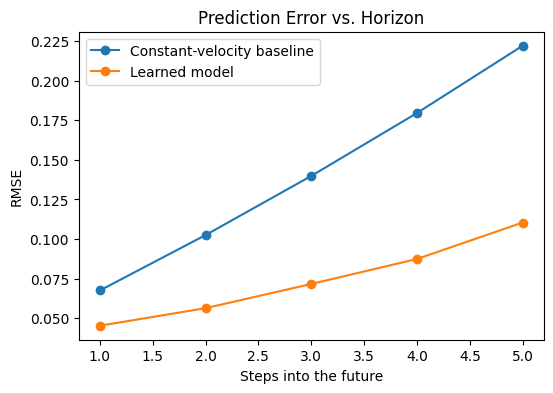

In [7]:
plt.figure(figsize=(6, 4))
steps = np.arange(1, M + 1)
plt.plot(steps, baseline_errors, marker='o', label='Constant-velocity baseline')
plt.plot(steps, model_errors, marker='o', label='Learned model')
plt.xlabel('Steps into the future')
plt.ylabel('RMSE')
plt.title('Prediction Error vs. Horizon')
plt.legend()
plt.show()

## One Trajectory, Visualized

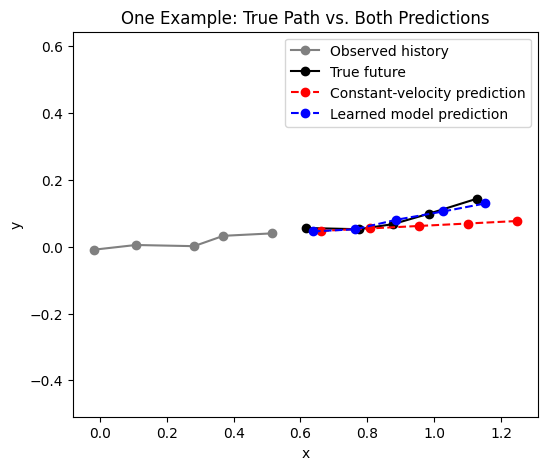

In [8]:
example_trajectory = generate_trajectory(np.random.default_rng(7))
history = example_trajectory[:K]
future = example_trajectory[K:K + M]
anchor = history[-1]

x_input = (history - anchor).flatten().reshape(-1, 1)
baseline_pred = constant_velocity_baseline(x_input).flatten().reshape(M, 2) + anchor
_, _, model_pred_rel = forward(x_input, W1, b1, W2, b2)
model_pred = model_pred_rel.flatten().reshape(M, 2) + anchor

plt.figure(figsize=(6, 5))
plt.plot(history[:, 0], history[:, 1], 'o-', color='gray', label='Observed history')
plt.plot(future[:, 0], future[:, 1], 'o-', color='black', label='True future')
plt.plot(baseline_pred[:, 0], baseline_pred[:, 1], 'o--', color='red', label='Constant-velocity prediction')
plt.plot(model_pred[:, 0], model_pred[:, 1], 'o--', color='blue', label='Learned model prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('One Example: True Path vs. Both Predictions')
plt.legend()
plt.axis('equal')
plt.show()

The constant-velocity baseline shoots off in a straight tangent line from the last observed point - exactly what it's defined to do. The learned model, having seen the curvature across the whole history window, should bend its prediction to follow the true path much more closely.

This connects directly to this team's scouting agent plans: a trajectory-prediction model like this one is a candidate source of the "video/visual features" input to the strategy agent's value/policy network from `ml_resources/rl_primer` - a forecast of where an opponent is *heading*, not just where they currently are, is exactly the kind of signal a defensive positioning recommendation would need.

## The Honest Limits of This Approach

This fixed-window approach is a real, legitimate technique - but it has real limits worth naming rather than glossing over. It can only ever look back exactly $K$ steps, no more and no less, and it has no way to learn *which* of those $K$ past points matter most for a specific prediction - every one of them is just another number in a fixed-size input vector. A trajectory that needs a longer memory (an opponent who juked several seconds ago in a way that's still informative now), or a model that should weigh recent points differently than older ones depending on the situation, needs an architecture built for variable-length sequences and learned attention over them - which is exactly why `perception_primer/05` pointed to **Transformer-based architectures** for the fully general version of this problem. That's out of scope here (it depends on a GenAI architecture primer this curriculum doesn't have yet), but it's worth knowing by name as the natural next step, not something this notebook is pretending doesn't exist.

## Try It Yourself

Add a second trajectory type to `generate_trajectory`: instead of a smooth constant-curvature arc, have the robot drive straight for the first half of the trajectory, then instantly switch to a sharp turn (a discontinuous change in `angular_velocity`) for the second half - a much more sudden "juke" than this notebook's smooth arcs. Generate a small test set of only this new trajectory type and evaluate both the baseline and the trained model (don't retrain) on it. Does the model's advantage over the baseline shrink, disappear, or reverse, for input windows that end *right before* the sudden turn happens? Write one sentence on why that result makes sense given what the model actually had access to in its input window.

In [9]:
# TODO: write a generate_sharp_turn_trajectory(rng) variant with a sudden mid-trajectory
# direction change, build a small test set from it, and evaluate (without retraining)
# both constant_velocity_baseline and the trained model against it


## Resources

- Alahi, A. et al. (2016). "Social LSTM: Human Trajectory Prediction in Crowded Spaces." *CVPR 2016*. An accessible entry point into learned trajectory prediction using sequence models, for the fully general version of this problem (paper).
- [Bewley et al. (2016), *Simple Online and Realtime Tracking*](https://arxiv.org/abs/1602.00763) - the SORT paper already linked from `perception_primer/05`; its Kalman-filter baseline is exactly what this notebook is extending past (paper).
- [3Blue1Brown: Neural Networks](https://www.3blue1brown.com/topics/neural-networks) - revisit once more if the regression-head reframing in this notebook felt unfamiliar (video).